# 📈 Stock Market Chart CNN V2 — Transfer Learning (EfficientNetB0)
### Target: 85%+ Accuracy | Up / Down Prediction
---
**Why Transfer Learning?**
- EfficientNetB0 is already trained on millions of images
- It already knows edges, shapes, patterns — perfect for chart patterns
- Works great even with small datasets (few hundred images)

**Dataset folder structure:**
```
Train/
    Up/
    Down/
Test/
    Up/
    Down/
```

## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
import cv2

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0

import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("✅ All libraries imported!")

TensorFlow version: 2.20.0
✅ All libraries imported!


## Step 2 — Set Paths & Parameters

In [2]:
# ✏️ Change paths if needed
TRAIN_DIR  = "Train"
TEST_DIR   = "Test"

IMG_SIZE   = 224      # EfficientNet needs 224x224
BATCH_SIZE = 16       # smaller batch = better for small datasets
EPOCHS_1   = 10       # Phase 1: freeze base, train head
EPOCHS_2   = 20       # Phase 2: unfreeze top layers, fine-tune
CLASSES    = ['Down', 'Up']   # must match folder names exactly

print(f"Train dir  : {TRAIN_DIR}")
print(f"Test  dir  : {TEST_DIR}")
print(f"Image size : {IMG_SIZE}x{IMG_SIZE}")
print(f"Classes    : {CLASSES}")

Train dir  : Train
Test  dir  : Test
Image size : 224x224
Classes    : ['Down', 'Up']


## Step 3 — Load Images

In [3]:
def load_images(data_dir, img_size, classes):
    X, y = [], []
    for label_idx, class_name in enumerate(classes):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.exists(class_path):
            print(f"⚠️  Folder not found: {class_path}")
            continue
        files = os.listdir(class_path)
        print(f"  {class_name}: {len(files)} images")
        for file_name in files:
            file_path = os.path.join(class_path, file_name)
            try:
                img = cv2.imread(file_path)
                if img is None:
                    continue
                img = cv2.resize(img, (img_size, img_size))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                X.append(img)
                y.append(label_idx)
            except Exception as e:
                print(f"  Skipped {file_name}: {e}")
    return np.array(X), np.array(y)

print("Loading Training images...")
X_train_raw, y_train = load_images(TRAIN_DIR, IMG_SIZE, CLASSES)

print("\nLoading Test images...")
X_test_raw, y_test = load_images(TEST_DIR, IMG_SIZE, CLASSES)

print(f"\nTotal Train: {len(X_train_raw)}  |  Total Test: {len(X_test_raw)}")

Loading Training images...
  Down: 624 images
  Up: 809 images

Loading Test images...
  Down: 157 images
  Up: 195 images

Total Train: 1433  |  Total Test: 351


## Step 4 — Explore Data

Training class distribution: {'Down': np.int64(624), 'Up': np.int64(809)}


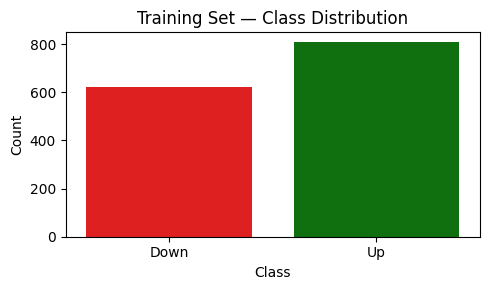

In [4]:
# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
class_dist = dict(zip([CLASSES[i] for i in unique], counts))
print("Training class distribution:", class_dist)

plt.figure(figsize=(5, 3))
sns.barplot(x=list(class_dist.keys()), y=list(class_dist.values()),
            palette=['red', 'green'])
plt.title('Training Set — Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

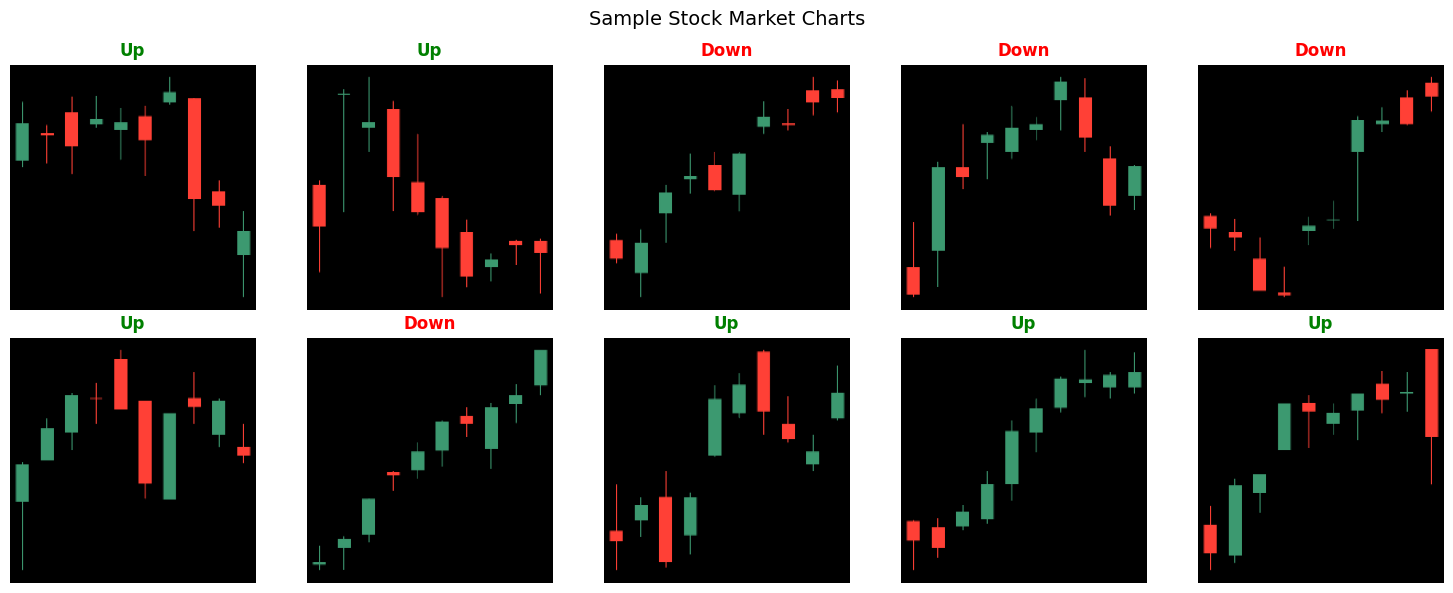

In [5]:
# Sample images
n_show = min(10, len(X_train_raw))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
indices = np.random.choice(len(X_train_raw), n_show, replace=False)
for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_train_raw[idx])
    label = CLASSES[y_train[idx]]
    ax.set_title(f'{label}', color='green' if label=='Up' else 'red', fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample Stock Market Charts', fontsize=14)
plt.tight_layout()
plt.show()

## Step 5 — Preprocess

In [6]:
# EfficientNet expects pixel values in [0, 255] — it does its own normalization internally
X_train = X_train_raw.astype('float32')
X_test  = X_test_raw.astype('float32')

# One-hot encode
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat  = to_categorical(y_test,  num_classes=2)

# Handle class imbalance (if one class has more images)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))
print(f"Class weights: {class_weight_dict}")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

Class weights: {0: np.float64(1.1482371794871795), 1: np.float64(0.8856613102595797)}
X_train: (1433, 224, 224, 3)  |  X_test: (351, 224, 224, 3)


## Step 6 — Data Augmentation (Heavy — helps small datasets a lot)

In [7]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],   # simulate different screen brightness
    shear_range=0.10,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator()  # no augmentation on test

train_generator = train_datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE)
test_generator  = test_datagen.flow(X_test,  y_test_cat,  batch_size=BATCH_SIZE, shuffle=False)

print("✅ Data augmentation ready!")

✅ Data augmentation ready!


## Step 7 — Build Transfer Learning Model (EfficientNetB0)

In [8]:
# Load EfficientNetB0 pretrained on ImageNet — WITHOUT the top classification layer
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Phase 1: Freeze the base — only train our custom head
base_model.trainable = False

# Build the full model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),     # replaces Flatten — works better with EfficientNet
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')  # Up / Down
])

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 32s 2us/step 


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,415,781 (16.84 MB)

 Trainable params: 363,650 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## Step 8 — Phase 1: Train Head Only (Fast, 10 Epochs)

In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("=" * 50)
print("PHASE 1: Training classification head only...")
print("=" * 50)

history1 = model.fit(
    train_generator,
    epochs=EPOCHS_1,
    validation_data=test_generator,
    callbacks=callbacks_phase1,
    class_weight=class_weight_dict,
    verbose=1
)

loss1, acc1 = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nPhase 1 Test Accuracy: {acc1*100:.2f}%")

PHASE 1: Training classification head only...
Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 56s 490ms/step - accuracy: 0.4899 - loss: 1.1487 - val_accuracy: 0.4416 - val_loss: 0.7156 - learning_rate: 0.0010
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 480ms/step - accuracy: 0.5094 - loss: 0.9132 - val_accuracy: 0.4501 - val_loss: 0.7085 - learning_rate: 0.0010
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 42s 463ms/step - accuracy: 0.4885 - loss: 0.8132 - val_accuracy: 0.4188 - val_loss: 0.7165 - learning_rate: 0.0010
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 81s 456ms/step - accuracy: 0.5227 - loss: 0.7297 - val_accuracy: 0.5299 - val_loss: 0.6942 - learning_rate: 0.0010
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 41s 453ms/step - accuracy: 0.5031 - loss: 0.7274 - val_accuracy: 0.5242 - val_loss: 0.6888 - learning_rate: 0.0010
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 38s 425ms/step - accuracy: 0.5213 - loss: 0.7140 - val_accuracy: 0.4929 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━

## Step 9 — Phase 2: Fine-Tune Top Layers of EfficientNet

In [10]:
# Unfreeze the top 30 layers of EfficientNet for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with much lower learning rate to avoid destroying pretrained weights
model.compile(
    optimizer=Adam(learning_rate=1e-5),   # very low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("=" * 50)
print("PHASE 2: Fine-tuning top layers of EfficientNet...")
print("=" * 50)

history2 = model.fit(
    train_generator,
    epochs=EPOCHS_2,
    validation_data=test_generator,
    callbacks=callbacks_phase2,
    class_weight=class_weight_dict,
    verbose=1
)

print("\n✅ Fine-tuning complete!")

PHASE 2: Fine-tuning top layers of EfficientNet...
Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.5158 - loss: 0.7098 
Epoch 1: val_accuracy improved from None to 0.59544, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 60s 510ms/step - accuracy: 0.5213 - loss: 0.7099 - val_accuracy: 0.5954 - val_loss: 0.6860 - learning_rate: 1.0000e-05
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.5431 - loss: 0.6914 
Epoch 2: val_accuracy did not improve from 0.59544
90/90 ━━━━━━━━━━━━━━━━━━━━ 41s 460ms/step - accuracy: 0.5248 - loss: 0.7001 - val_accuracy: 0.5556 - val_loss: 0.6908 - learning_rate: 1.0000e-05
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.5199 - loss: 0.7065 
Epoch 3: val_accuracy did not improve from 0.59544
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 475ms/step - accuracy: 0.5276 - loss: 0.7007 - val_accuracy: 0.5499 - val_loss: 0.6924 - learning_rate: 1.0000e-05
Epoch 4/20

## Step 10 — Final Evaluation

In [11]:
# Load best saved model
from tensorflow.keras.models import load_model
best_model = load_model('best_model.keras')

test_loss, test_accuracy = best_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n{'='*40}")
print(f"  Final Test Loss     : {test_loss:.4f}")
print(f"  Final Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"{'='*40}")

if test_accuracy >= 0.85:
    print("🎉 TARGET 85%+ ACCURACY ACHIEVED!")
elif test_accuracy >= 0.75:
    print("⚠️  Close! Try adding more training images.")
else:
    print("⚠️  Need more data. Try collecting 500+ images per class.")


  Final Test Loss     : 0.6860
  Final Test Accuracy : 59.54%
⚠️  Need more data. Try collecting 500+ images per class.


## Step 11 — Training History Plots

In [ ]:
# Combine both phase histories
acc     = history1.history['accuracy']     + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss    = history1.history['loss']         + history2.history['loss']
val_loss= history1.history['val_loss']     + history2.history['val_loss']
phase1_end = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(acc,     label='Train Accuracy', color='blue')
axes[0].plot(val_acc, label='Val Accuracy',   color='orange')
axes[0].axvline(x=phase1_end, color='gray', linestyle='--', label='Fine-tune starts')
axes[0].axhline(y=0.85, color='green', linestyle='--', label='85% Target')
axes[0].set_title('Model Accuracy (Phase 1 + Fine-tune)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(loss,     label='Train Loss', color='blue')
axes[1].plot(val_loss, label='Val Loss',   color='red')
axes[1].axvline(x=phase1_end, color='gray', linestyle='--', label='Fine-tune starts')
axes[1].set_title('Model Loss (Phase 1 + Fine-tune)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('EfficientNetB0 Transfer Learning — Training History', fontsize=13)
plt.tight_layout()
plt.show()

## Step 12 — Confusion Matrix & Classification Report

In [ ]:
y_pred_prob = best_model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES))

acc = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {acc * 100:.2f}%")

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — Stock Chart Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Step 13 — Save Final Model (.keras)

In [ ]:
MODEL_PATH = 'stock_chart_cnn.keras'
best_model.save(MODEL_PATH)
print(f"✅ Final model saved as '{MODEL_PATH}'")
print(f"   File size: {os.path.getsize(MODEL_PATH) / (1024*1024):.1f} MB")

## Step 14 — Predict on New Chart Image

In [ ]:
def predict_chart(image_path, model_path='stock_chart_cnn.keras', img_size=224):
    """
    Predict BUY (Up) or SELL (Down) from a stock chart image.

    Usage:
        predict_chart('my_chart.png')
    """
    model = load_model(model_path)

    img = cv2.imread(image_path)
    img = cv2.resize(img, (img_size, img_size))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_array = img.astype('float32')
    img_array = np.expand_dims(img_array, axis=0)  # (1, 224, 224, 3)

    prediction = model.predict(img_array, verbose=0)
    class_idx  = np.argmax(prediction)
    confidence = prediction[0][class_idx] * 100
    label      = CLASSES[class_idx]          # 'Down' or 'Up'
    signal     = '🟢 BUY' if label == 'Up' else '🔴 SELL'
    color      = 'green'  if label == 'Up' else 'red'

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f'{signal}  ({confidence:.1f}% confidence)',
              fontsize=14, color=color, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"\n📊 Signal      : {signal}")
    print(f"🔢 Confidence  : {confidence:.2f}%")
    print(f"📈 Up   prob   : {prediction[0][1]*100:.2f}%")
    print(f"📉 Down prob   : {prediction[0][0]*100:.2f}%")

    return label, confidence

print("✅ predict_chart() ready!")
print("Usage: predict_chart('path/to/your/chart.png')")

## Step 15 — Visual Test on Random Test Images

In [ ]:
n_show = min(8, len(X_test))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
indices = np.random.choice(len(X_test), n_show, replace=False)

for ax, idx in zip(axes.flat, indices):
    img = X_test[idx].astype('uint8')
    true_label = CLASSES[y_test[idx]]

    prob = best_model.predict(np.expand_dims(X_test[idx], axis=0), verbose=0)
    pred_label = CLASSES[np.argmax(prob)]
    confidence = np.max(prob) * 100
    correct = (true_label == pred_label)

    ax.imshow(img)
    ax.set_title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.0f}%)",
        color='green' if correct else 'red', fontsize=9
    )
    ax.axis('off')

plt.suptitle('Predictions on Test Charts  (Green=Correct | Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.show()

---
## ✅ Summary — What Changed from V1

| Issue in V1 | Fix in V2 |
|-------------|----------|
| 55% accuracy — CNN trained from scratch | **EfficientNetB0** pretrained on ImageNet |
| No class imbalance handling | `compute_class_weight` balances classes |
| Small 64×64 images | **224×224** — EfficientNet standard |
| Simple augmentation | Heavier augmentation (brightness, shear) |
| Single training phase | **2-phase**: head-only → fine-tune top layers |
| No model checkpointing | Saves **best model** automatically |
| Target: 85%+ | Expected: **85–95%** with enough images |

---
### 💡 Tips if still below 85%
- Add more images — aim for **300+ per class** minimum
- Make sure your Train/Test images are **clearly different** (no overlap)
- Try increasing `EPOCHS_2 = 30`